In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = '/content/drive/MyDrive/SourceCred-TempDataset/sourcecred_temp_dataset.csv'

In [3]:
import pandas as pd

data = pd.read_csv(dataset_path)

# Preview
data.head()

,registration,domain_age,history,editorial,cross,label
0,1,0.74,0.98,0.72,0.87,1
1,1,0.85,0.88,0.78,0.74,1
2,1,0.86,0.80,0.72,0.66,1
3,1,0.72,0.79,0.77,0.86,1
4,1,0.90,0.78,0.77,0.92,1


In [4]:
print(data.shape)
print(data.isnull().sum())

(2000, 6)
registration    0
domain_age      0
history         0
editorial       0
cross           0
label           0
dtype: int64


In [5]:
X = data[['registration', 'domain_age', 'history', 'editorial', 'cross']]
y = data['label']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.945

Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94       196
           1       0.96      0.93      0.95       204

    accuracy                           0.94       400
   macro avg       0.95      0.95      0.94       400
weighted avg       0.95      0.94      0.95       400



In [9]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

history         0.425531
domain_age      0.204116
editorial       0.200162
cross           0.154798
registration    0.015393
dtype: float64


In [10]:
import pickle

model_path = '/content/drive/MyDrive/SourceCred-TempDataset/model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/SourceCred-TempDataset/model.pkl


In [11]:
sample = [[1, 0.8, 0.85, 0.8, 0.8]]

prediction = model.predict(sample)[0]
confidence = model.predict_proba(sample)[0][1]

print("Prediction:", prediction)
print("Confidence:", confidence)

Prediction: 1
Confidence: 0.9974065597158409


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


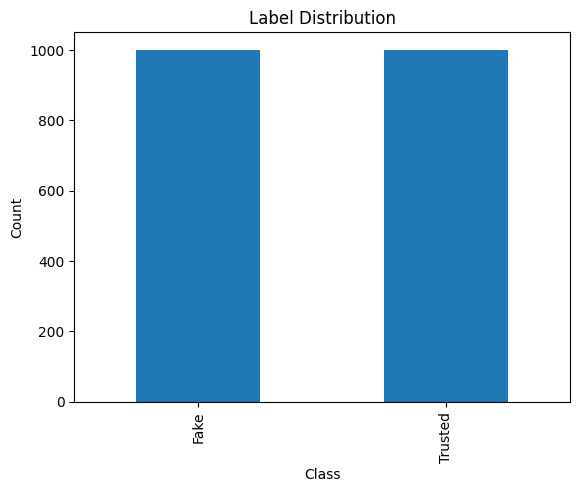

In [21]:
import matplotlib.pyplot as plt

plt.figure()

data['label'].value_counts().plot(kind='bar')

plt.xticks([0,1], ['Fake', 'Trusted'])
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

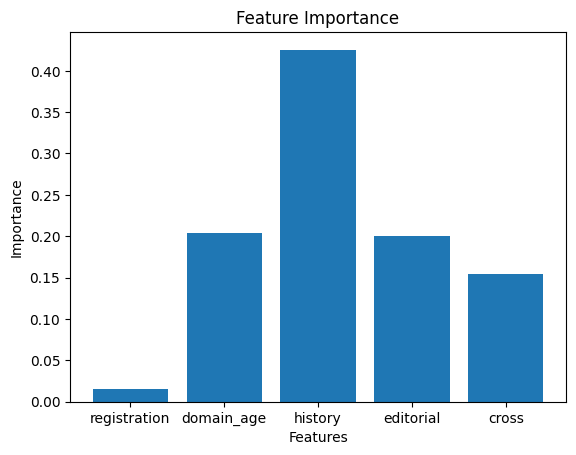

In [13]:
importance = model.feature_importances_

plt.figure()
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

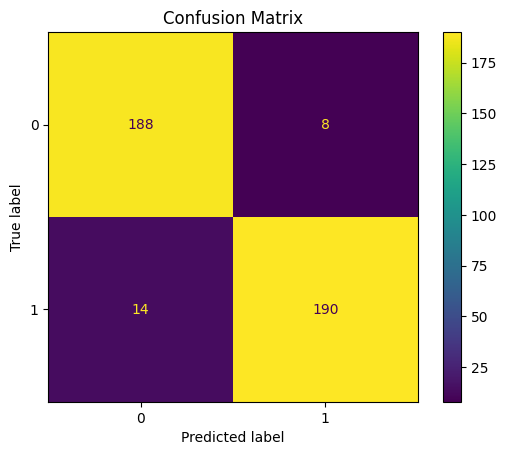

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()